<a href="https://colab.research.google.com/github/chpham92/chpham92/blob/main/PROJECT_RESEARCH_AGENT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Master Project: Build a Research Agent with LangGraph, GPT-4o, RAG, Pinecone, ArXiv and Google SerpAPI


In [1]:
pip install --upgrade pip -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 6.8 MB/s eta 0:00:00


In [2]:
import requests
import pandas as pd
import json
import xml.etree.ElementTree as ET
import os

# Namespace for ArXiv's Atom-based XML format.
ARXIV_NAMESPACE = '{http://www.w3.org/2005/Atom}'

def extract_from_arxiv(search_query='cat:cs.AI', max_results=100, json_file_path='files/arxiv_dataset.json'):
    """
    Fetches papers from the ArXiv API based on a search query, saves them as JSON,
    and returns a pandas DataFrame.

    Args:
        search_query (str): The search query for ArXiv (default is 'cat:cs.AI').
        max_results (int): The maximum number of results to retrieve (default is 100).
        json_file_path (str): File path where JSON data will be saved.

    Returns:
        pd.DataFrame: DataFrame containing the extracted paper information.
    """

    # Construct the URL for the API request.
    url = f'http://export.arxiv.org/api/query?search_query={search_query}&max_results={max_results}'

    # Send a GET request to the ArXiv API.
    response = requests.get(url)

    # Parse the XML response.
    root = ET.fromstring(response.content)

    papers = []

    # Loop through each "entry" in the XML, representing a single paper.
    for entry in root.findall(f'{ARXIV_NAMESPACE}entry'):
        title = entry.find(f'{ARXIV_NAMESPACE}title').text.strip()
        summary = entry.find(f'{ARXIV_NAMESPACE}summary').text.strip()

        # Get the authors of the paper.
        author_elements = entry.findall(f'{ARXIV_NAMESPACE}author')
        authors = [author.find(f'{ARXIV_NAMESPACE}name').text for author in author_elements]

        # Get the paper's URL.
        paper_url = entry.find(f'{ARXIV_NAMESPACE}id').text
        arxiv_id = paper_url.split('/')[-1]

        # Check for the PDF link.
        pdf_link = next((link.attrib['href'] for link in entry.findall(f'{ARXIV_NAMESPACE}link')
                         if link.attrib.get('title') == 'pdf'), None)

        papers.append({
            'title': title,
            'summary': summary,
            'authors': authors,
            'arxiv_id': arxiv_id,
            'url': paper_url,
            'pdf_link': pdf_link
        })

    # Convert list into a pandas DataFrame.
    df = pd.DataFrame(papers)

    # Ensure the directory exists before saving the file.
    os.makedirs(os.path.dirname(json_file_path), exist_ok=True)

    # Save the DataFrame to a JSON file.
    with open(json_file_path, 'w', encoding='utf-8') as f:
        json.dump(papers, f, ensure_ascii=False, indent=4)
        print(f'Data saved to {json_file_path} ...')

    return df

In [3]:
df = extract_from_arxiv(max_results=20)

Data saved to files/arxiv_dataset.json ...


In [4]:
import json
file_name = 'files/arxiv_dataset.json'
with open(file_name, 'r') as file:
  data = json.load(file)

print(data)

[{'title': 'A Deep Reinforcement Learning Approach for Ramp Metering Based on Traffic Video Data', 'summary': 'Ramp metering that uses traffic signals to regulate vehicle flows from the on-ramps has been widely implemented to improve vehicle mobility of the freeway. Previous studies generally update signal timings in real-time based on predefined traffic measures collected by point detectors, such as traffic volumes and occupancies. Comparing with point detectors, traffic cameras-which have been increasingly deployed on road networks-could cover larger areas and provide more detailed traffic information. In this work, we propose a deep reinforcement learning (DRL) method to explore the potential of traffic video data in improving the efficiency of ramp metering. The proposed method uses traffic video frames as inputs and learns the optimal control strategies directly from the high-dimensional visual inputs. A real-world case study demonstrates that, in comparison with a state-of-the-pr

In [5]:
import pandas as pd
df = pd.DataFrame(data)
df.sample(n=5)

,title,summary,authors,arxiv_id,url,pdf_link
7,Modelling Human Routines: Conceptualising Soci...,Our routines play an important role in a wide ...,"[Rijk Mercuur, Virginia Dignum, Catholijn M. J...",2012.11903v1,http://arxiv.org/abs/2012.11903v1,https://arxiv.org/pdf/2012.11903v1
5,Skeleton-based Approaches based on Machine Vis...,"Recently, skeleton-based approaches have achie...","[Jie Li, Binglin Li, Min Gao]",2012.12447v1,http://arxiv.org/abs/2012.12447v1,https://arxiv.org/pdf/2012.12447v1
9,Compliance Generation for Privacy Documents un...,Most prominent research today addresses compli...,"[David Restrepo Amariles, Aurore Clément Trous...",2012.12718v1,http://arxiv.org/abs/2012.12718v1,https://arxiv.org/pdf/2012.12718v1
0,A Deep Reinforcement Learning Approach for Ram...,Ramp metering that uses traffic signals to reg...,"[Bing Liu, Yu Tang, Yuxiong Ji, Yu Shen, Yuchu...",2012.12104v1,http://arxiv.org/abs/2012.12104v1,https://arxiv.org/pdf/2012.12104v1
19,Conditioning LSTM Decoder and Bi-directional A...,Applying neural-networks on Question Answering...,[Heguang Liu],1905.02019v1,http://arxiv.org/abs/1905.02019v1,https://arxiv.org/pdf/1905.02019v1


## 02 - Downloading the Research Papers (PDFs)

In [6]:
import pandas as pd
import requests
import os

def download_pdfs(df, download_folder='files'):
    """
    Downloads PDFs from URLs listed in the DataFrame and saves them to a specified folder.
    The file names are stored in a new column 'pdf_file_name' in the DataFrame.

    Args:
        df (pd.DataFrame): DataFrame containing a 'pdf_link' column with URLs to download.
        download_folder (str): Path to the folder where PDFs will be saved (default is 'files').

    Returns:
        pd.DataFrame: The original DataFrame with an additional 'pdf_file_name' column containing
                      the paths of the downloaded PDF files or None if the download failed.
    """

    if not os.path.exists(download_folder):
        os.makedirs(download_folder)

    pdf_file_names = []

    # Loop through each row to download PDFs
    for index, row in df.iterrows():
        pdf_link = row['pdf_link']

        try:
            response = requests.get(pdf_link)
            response.raise_for_status()

            file_name = os.path.join(download_folder, pdf_link.split('/')[-1]) + '.pdf'
            pdf_file_names.append(file_name)

            # Save the downloaded PDF
            with open(file_name, 'wb') as f:
                f.write(response.content)

            print(f'PDF downloaded successfully and saved as {file_name}')

        except requests.exceptions.RequestException as e:
            print(f'Failed to download the PDF: {e}')
            pdf_file_names.append(None)

    df['pdf_file_name'] = pdf_file_names

    return df


In [7]:
df = download_pdfs(df)

PDF downloaded successfully and saved as files/2012.12104v1.pdf
PDF downloaded successfully and saved as files/2012.13026v1.pdf
PDF downloaded successfully and saved as files/2012.13293v1.pdf
PDF downloaded successfully and saved as files/2012.13315v1.pdf
PDF downloaded successfully and saved as files/2012.13391v2.pdf
PDF downloaded successfully and saved as files/2012.12447v1.pdf
PDF downloaded successfully and saved as files/2012.12634v1.pdf
PDF downloaded successfully and saved as files/2012.11903v1.pdf
PDF downloaded successfully and saved as files/2012.13569v1.pdf
PDF downloaded successfully and saved as files/2012.12718v1.pdf
PDF downloaded successfully and saved as files/2012.13666v1.pdf
PDF downloaded successfully and saved as files/2012.13677v1.pdf
PDF downloaded successfully and saved as files/2012.13779v1.pdf
PDF downloaded successfully and saved as files/2012.14005v1.pdf
PDF downloaded successfully and saved as files/1904.07934v2.pdf
PDF downloaded successfully and saved as

In [8]:
df

,title,summary,authors,arxiv_id,url,pdf_link,pdf_file_name
0,A Deep Reinforcement Learning Approach for Ram...,Ramp metering that uses traffic signals to reg...,"[Bing Liu, Yu Tang, Yuxiong Ji, Yu Shen, Yuchu...",2012.12104v1,http://arxiv.org/abs/2012.12104v1,https://arxiv.org/pdf/2012.12104v1,files/2012.12104v1.pdf
1,Rethink AI-based Power Grid Control: Diving In...,"Recently, deep reinforcement learning (DRL)-ba...","[Xiren Zhou, Siqi Wang, Ruisheng Diao, Desong ...",2012.13026v1,http://arxiv.org/abs/2012.13026v1,https://arxiv.org/pdf/2012.13026v1,files/2012.13026v1.pdf
2,Fuzzy Commitments Offer Insufficient Protectio...,"In this work, we study the protection that fuz...","[Danny Keller, Margarita Osadchy, Orr Dunkelman]",2012.13293v1,http://arxiv.org/abs/2012.13293v1,https://arxiv.org/pdf/2012.13293v1,files/2012.13293v1.pdf
3,Generalization in portfolio-based algorithm se...,Portfolio-based algorithm selection has seen t...,"[Maria-Florina Balcan, Tuomas Sandholm, Ellen ...",2012.13315v1,http://arxiv.org/abs/2012.13315v1,https://arxiv.org/pdf/2012.13315v1,files/2012.13315v1.pdf
4,"I like fish, especially dolphins: Addressing C...",To quantify how well natural language understa...,"[Yixin Nie, Mary Williamson, Mohit Bansal, Dou...",2012.13391v2,http://arxiv.org/abs/2012.13391v2,https://arxiv.org/pdf/2012.13391v2,files/2012.13391v2.pdf
5,Skeleton-based Approaches based on Machine Vis...,"Recently, skeleton-based approaches have achie...","[Jie Li, Binglin Li, Min Gao]",2012.12447v1,http://arxiv.org/abs/2012.12447v1,https://arxiv.org/pdf/2012.12447v1,files/2012.12447v1.pdf
6,Overview of FPGA deep learning acceleration ba...,"In recent years, deep learning has become more...",[Simin Liu],2012.12634v1,http://arxiv.org/abs/2012.12634v1,https://arxiv.org/pdf/2012.12634v1,files/2012.12634v1.pdf
7,Modelling Human Routines: Conceptualising Soci...,Our routines play an important role in a wide ...,"[Rijk Mercuur, Virginia Dignum, Catholijn M. J...",2012.11903v1,http://arxiv.org/abs/2012.11903v1,https://arxiv.org/pdf/2012.11903v1,files/2012.11903v1.pdf
8,Dynamic-K Recommendation with Personalized Dec...,"In this paper, we investigate the recommendati...","[Yan Gao, Jiafeng Guo, Yanyan Lan, Huaming Liao]",2012.13569v1,http://arxiv.org/abs/2012.13569v1,https://arxiv.org/pdf/2012.13569v1,files/2012.13569v1.pdf
9,Compliance Generation for Privacy Documents un...,Most prominent research today addresses compli...,"[David Restrepo Amariles, Aurore Clément Trous...",2012.12718v1,http://arxiv.org/abs/2012.12718v1,https://arxiv.org/pdf/2012.12718v1,files/2012.12718v1.pdf


## 03 - Loading and Splitting PDF Files into Chunks, Expanding the DataFrame

In [9]:
!pip install -q langchain-community langchain-text-splitters
#==load and split==
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [10]:
#==load and split==
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

def load_and_chunk_pdf(pdf_file_name, chunk_size=512):
    """
    Loads a PDF file and splits its content into chunks of a specified size.

    Args:
        file (str): Path to the PDF file to be loaded.
        chunk_size (int): The maximum size of each chunk in characters (default is 512).

    Returns:
        List[Document]: A list of document chunks.
    """

    print(f'Loading and splitting into chunks: {pdf_file_name}')

    # Load the content of the PDF
    loader = PyPDFLoader(pdf_file_name)
    data = loader.load()

    # Split the content into chunks with slight overlap to preserve context
    text_splitter = RecursiveCharacterTextSplitter(chunk_size=chunk_size, chunk_overlap=64)
    chunks = text_splitter.split_documents(data)

    return chunks


In [11]:
def expand_df(df):
    """
    Expands each row in the DataFrame by splitting PDF documents into chunks.

    Args:
        df (pd.DataFrame): DataFrame containing 'pdf_file_name', 'arxiv_id', 'title', 'summary',
                           'authors', and 'url' columns.

    Returns:
        pd.DataFrame: A new DataFrame where each row represents a chunk of the original document,
                      with additional metadata such as chunk identifiers and relationships to
                      adjacent chunks.
    """

    expanded_rows = []  # List to store expanded rows with chunk information

    # Loop through each row in the DataFrame
    for idx, row in df.iterrows():
        try:
            chunks = load_and_chunk_pdf(row['pdf_file_name'])
        except Exception as e:
            print(f"Error processing file {row['pdf_file_name']}: {e}")
            continue

        # Loop over the chunks and construct a new DataFrame row for each
        for i, chunk in enumerate(chunks):
            prechunk_id = i-1 if i > 0 else ''  # Preceding chunk ID
            postchunk_id = i+1 if i < len(chunks) - 1 else ''  # Following chunk ID

            expanded_rows.append({
                'id': f"{row['arxiv_id']}#{i}",  # Unique chunk identifier
                'title': row['title'],
                'summary': row['summary'],
                'authors': row['authors'],
                'arxiv_id': row['arxiv_id'],
                'url': row['url'],
                'chunk': chunk.page_content,  # Text content of the chunk
                'prechunk_id': '' if i == 0 else f"{row['arxiv_id']}#{prechunk_id}",  # Previous chunk ID
                'postchunk_id': '' if i == len(chunks) - 1 else f"{row['arxiv_id']}#{postchunk_id}"  # Next chunk ID
            })

    # Return a new expanded DataFrame
    return pd.DataFrame(expanded_rows)


In [12]:
pip install pypdf

In [13]:
expanded_df = expand_df(df)

Loading and splitting into chunks: files/2012.12104v1.pdf
Loading and splitting into chunks: files/2012.13026v1.pdf
Loading and splitting into chunks: files/2012.13293v1.pdf
Loading and splitting into chunks: files/2012.13315v1.pdf
Loading and splitting into chunks: files/2012.13391v2.pdf
Loading and splitting into chunks: files/2012.12447v1.pdf
Loading and splitting into chunks: files/2012.12634v1.pdf
Loading and splitting into chunks: files/2012.11903v1.pdf
Loading and splitting into chunks: files/2012.13569v1.pdf
Loading and splitting into chunks: files/2012.12718v1.pdf
Loading and splitting into chunks: files/2012.13666v1.pdf
Loading and splitting into chunks: files/2012.13677v1.pdf
Loading and splitting into chunks: files/2012.13779v1.pdf
Loading and splitting into chunks: files/2012.14005v1.pdf
Loading and splitting into chunks: files/1904.07934v2.pdf
Loading and splitting into chunks: files/1904.08010v1.pdf
Loading and splitting into chunks: files/1905.02810v1.pdf
Loading and sp

In [14]:
expanded_df

,id,title,summary,authors,arxiv_id,url,chunk,prechunk_id,postchunk_id
0,2012.12104v1#0,A Deep Reinforcement Learning Approach for Ram...,Ramp metering that uses traffic signals to reg...,"[Bing Liu, Yu Tang, Yuxiong Ji, Yu Shen, Yuchu...",2012.12104v1,http://arxiv.org/abs/2012.12104v1,1 \nA Deep Reinforcement Learning Approach for...,,2012.12104v1#1
1,2012.12104v1#1,A Deep Reinforcement Learning Approach for Ram...,Ramp metering that uses traffic signals to reg...,"[Bing Liu, Yu Tang, Yuxiong Ji, Yu Shen, Yuchu...",2012.12104v1,http://arxiv.org/abs/2012.12104v1,Abstract \nRamp metering that uses traffic sig...,2012.12104v1#0,2012.12104v1#2
2,2012.12104v1#2,A Deep Reinforcement Learning Approach for Ram...,Ramp metering that uses traffic signals to reg...,"[Bing Liu, Yu Tang, Yuxiong Ji, Yu Shen, Yuchu...",2012.12104v1,http://arxiv.org/abs/2012.12104v1,and provide more detailed traffic information....,2012.12104v1#1,2012.12104v1#3
3,2012.12104v1#3,A Deep Reinforcement Learning Approach for Ram...,Ramp metering that uses traffic signals to reg...,"[Bing Liu, Yu Tang, Yuxiong Ji, Yu Shen, Yuchu...",2012.12104v1,http://arxiv.org/abs/2012.12104v1,method results in 1) lower travel times in the...,2012.12104v1#2,2012.12104v1#4
4,2012.12104v1#4,A Deep Reinforcement Learning Approach for Ram...,Ramp metering that uses traffic signals to reg...,"[Bing Liu, Yu Tang, Yuxiong Ji, Yu Shen, Yuchu...",2012.12104v1,http://arxiv.org/abs/2012.12104v1,2 \nIntroduction \nRamp metering uses traffic ...,2012.12104v1#3,2012.12104v1#5
...,...,...,...,...,...,...,...,...,...
2134,1905.02019v1#27,Conditioning LSTM Decoder and Bi-directional A...,Applying neural-networks on Question Answering...,[Heguang Liu],1905.02019v1,http://arxiv.org/abs/1905.02019v1,Prediction: stephen colbert\nReason and Propos...,1905.02019v1#26,1905.02019v1#28
2135,1905.02019v1#28,Conditioning LSTM Decoder and Bi-directional A...,Applying neural-networks on Question Answering...,[Heguang Liu],1905.02019v1,http://arxiv.org/abs/1905.02019v1,5.2.4 Inaccurate boundary\nContext: The Super ...,1905.02019v1#27,1905.02019v1#29
2136,1905.02019v1#29,Conditioning LSTM Decoder and Bi-directional A...,Applying neural-networks on Question Answering...,[Heguang Liu],1905.02019v1,http://arxiv.org/abs/1905.02019v1,information. We can tokenize ”the most” into [...,1905.02019v1#28,1905.02019v1#30
2137,1905.02019v1#30,Conditioning LSTM Decoder and Bi-directional A...,Applying neural-networks on Question Answering...,[Heguang Liu],1905.02019v1,http://arxiv.org/abs/1905.02019v1,characters format feature 2) introducing part-...,1905.02019v1#29,1905.02019v1#31


## 04 - Building a Knowledge Base for the RAG System Using Embedding

In [15]:
from google.colab import userdata
api_key = userdata.get('OPENAI_API_KEY_RAG')

In [16]:
!pip install --upgrade semantic-router tiktoken -q
import os
from getpass import getpass
from semantic_router.encoders import OpenAIEncoder

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-openai 1.2.1 requires openai<3.0.0,>=2.26.0, but you have openai 2.24.0 which is incompatible.


In [17]:
# Initialize the OpenAIEncoder with a specific model
os.environ['OPENAI_API_KEY'] = api_key
encoder = OpenAIEncoder(name='text-embedding-3-small')

In [18]:
encoder('hello hallo hola salut')

[[0.013671875,
  0.006458282470703125,
  0.01934814453125,
  0.0301666259765625,
  0.0152130126953125,
  0.0020351409912109375,
  -0.003170013427734375,
  0.05096435546875,
  -0.01541900634765625,
  -0.050018310546875,
  0.01287078857421875,
  -0.0014829635620117188,
  -0.07098388671875,
  -0.00458526611328125,
  0.024505615234375,
  0.01288604736328125,
  -0.0240020751953125,
  -0.0032215118408203125,
  0.01422119140625,
  0.041473388671875,
  -0.0208740234375,
  0.033721923828125,
  0.0411376953125,
  0.039276123046875,
  0.007389068603515625,
  -0.00936126708984375,
  -0.01052093505859375,
  -0.0139617919921875,
  0.0289306640625,
  -0.015594482421875,
  0.03472900390625,
  -0.03277587890625,
  0.0271148681640625,
  -0.029205322265625,
  -0.007694244384765625,
  0.044097900390625,
  -0.04931640625,
  0.043182373046875,
  -0.02685546875,
  0.0228424072265625,
  -0.010345458984375,
  0.0002448558807373047,
  -0.0017795562744140625,
  -0.0211334228515625,
  0.0316162109375,
  0.0331420

In [19]:
dims = len(encoder('hello hallo hola salut')[0])
dims

1536

## 05 - Creating a Pinecone Index

In [20]:
pip install pinecone

In [21]:
from google.colab import userdata
api_key = userdata.get('PINECONE_API_KEY')

In [22]:
from pinecone import Pinecone, ServerlessSpec
import os


# Initialize the Pinecone client
pc = Pinecone(api_key=api_key)

# Define the serverless specification for Pinecone
spec = ServerlessSpec(
    cloud='aws',
    region='us-east-1'
)

In [23]:
import time

# Define the name of the index
index_name = 'langgraph-research-agent'

# Check if the index exists; create it if it doesn't
if index_name not in pc.list_indexes().names():
  pc.create_index(
      index_name,
      dimension=dims, # Embedding dimensions
      metric='cosine',
      spec=spec # Cloud provider and region specifics
  )

  # Wait until the index is fully initialized
  while not pc.describe_index(index_name).status['ready']:
    time.sleep(1)

# Connect to the index
index = pc.Index(index_name)

# Add a short delay before checking the stats
time.sleep(1)

# View the index statistics
index.describe_index_stats()

{'_response_info': {'raw_headers': {'connection': 'keep-alive',
                                    'content-length': '188',
                                    'content-type': 'application/json',
                                    'date': 'Thu, 30 Apr 2026 18:48:40 GMT',
                                    'grpc-status': '0',
                                    'server': 'envoy',
                                    'x-envoy-upstream-service-time': '82',
                                    'x-pinecone-request-latency-ms': '45',
                                    'x-pinecone-response-duration-ms': '83'}},
 'dimension': 1536,
 'index_fullness': 0.0,
 'memoryFullness': 0.0,
 'metric': 'cosine',
 'namespaces': {'__default__': {'vector_count': 2139}},
 'storageFullness': 0.0,
 'total_vector_count': 2139,
 'vector_type': 'dense'}

## 06 - Populating the Knowledge Base and Uploading it to Pinecone

In [24]:
expanded_df.iloc[:5]

,id,title,summary,authors,arxiv_id,url,chunk,prechunk_id,postchunk_id
0,2012.12104v1#0,A Deep Reinforcement Learning Approach for Ram...,Ramp metering that uses traffic signals to reg...,"[Bing Liu, Yu Tang, Yuxiong Ji, Yu Shen, Yuchu...",2012.12104v1,http://arxiv.org/abs/2012.12104v1,1 \nA Deep Reinforcement Learning Approach for...,,2012.12104v1#1
1,2012.12104v1#1,A Deep Reinforcement Learning Approach for Ram...,Ramp metering that uses traffic signals to reg...,"[Bing Liu, Yu Tang, Yuxiong Ji, Yu Shen, Yuchu...",2012.12104v1,http://arxiv.org/abs/2012.12104v1,Abstract \nRamp metering that uses traffic sig...,2012.12104v1#0,2012.12104v1#2
2,2012.12104v1#2,A Deep Reinforcement Learning Approach for Ram...,Ramp metering that uses traffic signals to reg...,"[Bing Liu, Yu Tang, Yuxiong Ji, Yu Shen, Yuchu...",2012.12104v1,http://arxiv.org/abs/2012.12104v1,and provide more detailed traffic information....,2012.12104v1#1,2012.12104v1#3
3,2012.12104v1#3,A Deep Reinforcement Learning Approach for Ram...,Ramp metering that uses traffic signals to reg...,"[Bing Liu, Yu Tang, Yuxiong Ji, Yu Shen, Yuchu...",2012.12104v1,http://arxiv.org/abs/2012.12104v1,method results in 1) lower travel times in the...,2012.12104v1#2,2012.12104v1#4
4,2012.12104v1#4,A Deep Reinforcement Learning Approach for Ram...,Ramp metering that uses traffic signals to reg...,"[Bing Liu, Yu Tang, Yuxiong Ji, Yu Shen, Yuchu...",2012.12104v1,http://arxiv.org/abs/2012.12104v1,2 \nIntroduction \nRamp metering uses traffic ...,2012.12104v1#3,2012.12104v1#5


In [25]:
from tqdm.auto import tqdm

data = expanded_df
batch_size = 64

# Loop through the data in batches, using tqdm for a progress bar
for i in tqdm(range(0, len(data), batch_size)):
  i_end = min(len(data), i + batch_size) # define batch endpoint
  batch = data[i:i_end].to_dict(orient='records')

  # Extract metadata for each chunk in the batch
  metadata = [{
      'arxiv_id': r['arxiv_id'],
      'title': r['title'],
      'chunk': r['chunk'],
  } for r in batch]

  # Generate unique IDs for each chunk
  ids = [r['id'] for r in batch]

  # Extract the chunk content
  chunks = [r['chunk'] for r in batch]

  # Convert chunks into embeddings
  embeds = encoder(chunks)

  # Upload embeddings, IDs, and metadata ito Pinecone
  index.upsert(vectors=zip(ids, embeds, metadata))

  0%|          | 0/34 [00:00<?, ?it/s]

In [26]:
# Display the index statistics
index.describe_index_stats()

{'_response_info': {'raw_headers': {'connection': 'keep-alive',
                                    'content-length': '188',
                                    'content-type': 'application/json',
                                    'date': 'Thu, 30 Apr 2026 18:49:33 GMT',
                                    'grpc-status': '0',
                                    'server': 'envoy',
                                    'x-envoy-upstream-service-time': '2',
                                    'x-pinecone-request-latency-ms': '2',
                                    'x-pinecone-response-duration-ms': '3'}},
 'dimension': 1536,
 'index_fullness': 0.0,
 'memoryFullness': 0.0,
 'metric': 'cosine',
 'namespaces': {'__default__': {'vector_count': 2139}},
 'storageFullness': 0.0,
 'total_vector_count': 2139,
 'vector_type': 'dense'}

## 07 - Implementing the ArXiv Fetch Tool

In [27]:
import requests
# Specify the Arxiv ID for the paper
arxiv_id = '1706.03762'

# Make a GET request to retrieve the page for the specified paper
res = requests.get(f"https://arxiv.org/abs/{arxiv_id}")

# Access the content of the response as a string (HTML)
res.text

'<!DOCTYPE html>\n<html lang="en">\n\n<head>  <title>[1706.03762] Attention Is All You Need</title>\n  <meta name="viewport" content="width=device-width, initial-scale=1">\n  <link rel="apple-touch-icon" sizes="180x180" href="/static/browse/0.3.4/images/icons/apple-touch-icon.png">\n  <link rel="icon" type="image/png" sizes="32x32" href="/static/browse/0.3.4/images/icons/favicon-32x32.png">\n  <link rel="icon" type="image/png" sizes="16x16" href="/static/browse/0.3.4/images/icons/favicon-16x16.png">\n  <link rel="manifest" href="/static/browse/0.3.4/images/icons/site.webmanifest">\n  <link rel="mask-icon" href="/static/browse/0.3.4/images/icons/safari-pinned-tab.svg" color="#5bbad5">\n  <meta name="msapplication-TileColor" content="#da532c">\n  <meta name="theme-color" content="#ffffff">\n  <link rel="stylesheet" type="text/css" media="screen" href="/static/browse/0.3.4/css/arXiv.css?v=20260318" />\n  <link rel="stylesheet" type="text/css" media="print" href="/static/browse/0.3.4/css/a

In [28]:
import re

# Compile a regular expression pattern to find the abstract in the HTML response
abstract_pattern = re.compile(
    r'<blockquote class="abstract mathjax">\s*<span class="descriptor">Abstract:</span>\s*(.*?)\s*</blockquote>',
    re.DOTALL
)

# Search for the abstract in the HTML response text
re_match = abstract_pattern.search(res.text)

# Check if the abstract was found and print it; otherwise, display an error message
if re_match:
    print(re_match.group(1))
else:
    print('Abstract not found.')

The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, based solely on attention mechanisms, dispensing with recurrence and convolutions entirely. Experiments on two machine translation tasks show these models to be superior in quality while being more parallelizable and requiring significantly less time to train. Our model achieves 28.4 BLEU on the WMT 2014 English-to-German translation task, improving over the existing best results, including ensembles by over 2 BLEU. On the WMT 2014 English-to-French translation task, our model establishes a new single-model state-of-the-art BLEU score of 41.8 after training for 3.5 days on eight GPUs, a small fraction of the training costs of the best models from the literature. We show that the Transforme

In [29]:
from langchain_core.tools import tool
import requests
import re

# Compile a regular expression pattern to find the abstract in the HTML response
abstract_pattern = re.compile(
    r'<blockquote class="abstract mathjax">\s*<span class="descriptor">Abstract:</span>\s*(.*?)\s*</blockquote>',
    re.DOTALL
)

@tool('fetch_arxiv')
def fetch_arxiv(arxiv_id: str) -> str:
    '''Fetches the abstract from an ArXiv paper given its ArXiv ID.

    Args:
        arxiv_id (str): The ArXiv paper ID.

    Returns:
        str: The extracted abstract text from the ArXiv paper.
    '''

    res = requests.get(f'https://arxiv.org/abs/{arxiv_id}')

    re_match = abstract_pattern.search(res.text)

    return re_match.group(1) if re_match else 'Abstract not found.'


In [30]:
# Defining the Arxiv paper ID and invoking the tool with the ID
arxiv_id = '1706.03762'
output = fetch_arxiv.invoke(input={'arxiv_id': arxiv_id})
print(output)

The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, based solely on attention mechanisms, dispensing with recurrence and convolutions entirely. Experiments on two machine translation tasks show these models to be superior in quality while being more parallelizable and requiring significantly less time to train. Our model achieves 28.4 BLEU on the WMT 2014 English-to-German translation task, improving over the existing best results, including ensembles by over 2 BLEU. On the WMT 2014 English-to-French translation task, our model establishes a new single-model state-of-the-art BLEU score of 41.8 after training for 3.5 days on eight GPUs, a small fraction of the training costs of the best models from the literature. We show that the Transforme

## 08 - Implementing the Web Search Tools with Google SerpAPI

In [31]:
!pip install serpapi
!pip install googlesearch-python

In [31]:
import serpapi
from google.colab import userdata
api_key = userdata.get('SERPAPI_API_KEY')
import os
from getpass import getpass


# Perform a Google search for the keyword "water" and limit the results to 5.
client = serpapi.Client(api_key=api_key)
results = client.search(q="water", engine="google")


# Extract the main search results from the API response.
results = results.get('organic_results', [])

# Format the search results for readability.
formatted_results = '\n---\n'.join(
    ['\n'.join([x['title'], x['snippet'], x['link']]) for x in results]
)


In [32]:
print(formatted_results)

Water
Water is an inorganic compound with the chemical formula H 2 O. It is a transparent, tasteless, odorless, [c] and nearly colorless chemical substance
https://en.wikipedia.org/wiki/Water
---
Tyla - Water (Official Music Video)
Tyla - Water (Official Music Video) Listen To “Water” now: https://Tyla.lnk.to/Water Watch the Official Music Video: ...
https://www.youtube.com/watch?v=XoiOOiuH8iI
---
Water | H2O | CID 962
Water | H2O | CID 962 - structure, chemical names, physical and chemical properties, classification, patents, literature, biological activities, ...
https://pubchem.ncbi.nlm.nih.gov/compound/Water
---
UN-Water | Coordinating the UN's work on water and sanitation
The first-ever UN System-wide Strategy for Water and Sanitation unites UN support to countries to accelerate progress on water-related goals and targets.
https://www.unwater.org/
---
Water | An Open Access Journal from MDPI
Water is a peer-reviewed, open access journal on water science and technology, including t

In [33]:
from langchain_core.tools import tool
import serpapi
from google.colab import userdata

@tool('web_search')
def web_search(query: str) -> str:
    '''Performs a Google search using SerpAPI for a given query.

    Args:
        query (str): The search query.

    Returns:
        str: Formatted search results including title, snippet, and link for each result.
    '''
    api_key = userdata.get('SERPAPI_API_KEY')
    client = serpapi.Client(api_key=api_key)
    results = client.search(q=query, engine="google")

    # Extract the main search results from the API response.
    organic_results = results.get('organic_results', [])

    # Format the search results for readability.
    formatted_results = '\n---\n'.join(
        ['\n'.join([x.get('title', ''), x.get('snippet', ''), x.get('link', '')]) for x in organic_results]
    )
    return formatted_results

In [34]:
# Invoke the 'web_search' tool with the query 'water on mars'
output = web_search.invoke(input={'query': 'water on mars'})
print(output)

Water on Mars
Mars contains water, though mostly as subsurface permafrost. Surface water is readily visible at some places, such as the ice-filled Korolev Crater, near the ...
https://en.wikipedia.org/wiki/Water_on_Mars
---
Water on Mars: The Story So Far | News
Although the surface of Mars is presently cold and dry, plenty of evidence suggests that the red planet was once partly covered with water.
https://astrobiology.nasa.gov/news/water-on-mars-the-story-so-far/
---
Scientists find oceans of water on Mars. It's just too deep to ...
A new analysis of Mars' interior suggests that much of the liquid water still exists in the pores of rocks 10-20 kilometers below the surface.
https://news.berkeley.edu/2024/08/12/scientists-find-oceans-of-water-on-mars-its-just-too-deep-to-tap/
---
Scientists have discovered a reservoir of liquid water on Mars
While there is water frozen at the Martian poles and evidence of vapour in the atmosphere, this is the first time liquid water has been found on .

## 09 - Creating RAG Tools for Retrieval-Augmented Generation (RAG)

In [35]:
def format_rag_contexts(matches: list) -> str:
    '''Formats the retrieved context matches into a readable string format.

    Args:
        matches (list): A list of matched documents with metadata.

    Returns:
        str: A formatted string of document titles, chunks, and ArXiv IDs.
    '''
    formatted_results = []

    # Loop through each match and extract its metadata.
    for x in matches:
        text = (
            f"Title: {x['metadata']['title']}\n"
            f"Chunk: {x['metadata']['chunk']}\n"
            f"ArXiv ID: {x['metadata']['arxiv_id']}\n"
        )
        # Append each formatted string to the results list.
        formatted_results.append(text)

    # Join all the individual formatted strings into one large string.
    return '\n---\n'.join(formatted_results)


In [36]:
from langchain_core.tools import tool

@tool
def rag_search_filter(query: str, arxiv_id: str) -> str:
    '''Finds information from the ArXiv database using a natural language query and a specific ArXiv ID.

    Args:
        query (str): The search query in natural language.
        arxiv_id (str): The ArXiv ID of the specific paper to filter by.

    Returns:
        str: A formatted string of relevant document contexts.
    '''

    # Encode the query into a vector representation.
    xq = encoder([query])

    # Perform a search on the Pinecone index, filtering by ArXiv ID.
    xc = index.query(vector=xq, top_k=6, include_metadata=True, filter={'arxiv_id': arxiv_id})

    # Format and return the search results.
    return format_rag_contexts(xc['matches'])


In [37]:
@tool('rag_search')
def rag_search(query: str) -> str:
    '''Finds specialist information on AI using a natural language query.

    Args:
        query (str): The search query in natural language.

    Returns:
        str: A formatted string of relevant document contexts.
    '''

    # Encode the query into a vector representation.
    xq = encoder([query])

    # Perform a broader search without filtering by ArXiv ID.
    xc = index.query(vector=xq, top_k=5, include_metadata=True)

    # Format and return the search results.
    return format_rag_contexts(xc['matches'])


## 10 - Implementing the Final Answer Generation Tool

In [38]:
from langchain_core.tools import tool
from typing import List # Import List from typing

# Define the 'final_answer' tool to compile the research report
@tool
def final_answer(
    introduction: str,
    research_steps: List[str], # Change type hint to List[str]
    main_body: str,
    conclusion: str,
    sources: List[str] # Change type hint to List[str]
) -> str:
    '''Returns a natural language response in the form of a research report.

    Args:
        introduction (str): A short paragraph introducing the user's question and the topic.
        research_steps (List[str]): Bullet points or text explaining the steps taken for research.
        main_body (str): The bulk of the answer, 3-4 paragraphs long, providing high-quality information.
        conclusion (str): A short paragraph summarizing the findings.
        sources (List[str]): A list or text providing the sources referenced during the research.

    Returns:
        str: A formatted research report string.
    '''

    # Format research steps if given as a list
    # (This check is now redundant if type hint is List[str], but harmless)
    research_steps_formatted = '\n'.join([f'- {r}' for r in research_steps])

    # Format sources if given as a list
    # (This check is now redundant if type hint is List[str], but harmless)
    sources_formatted = '\n'.join([f'- {s}' for s in sources])

    # Construct and return the final research report
    return f'{introduction}\n\nResearch Steps:\n{research_steps_formatted}\n\nMain Body:\n{main_body}\n\n \
    Conclusion:\n{conclusion}\n\nSources:\n{sources_formatted}'


## 11 - Initializing the "Oracle" LLM

In [39]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

# Define the system prompt guiding the AI's decision-making process.
system_prompt = (
    '''You are the oracle, the great AI decision-maker.
    Given the user's query, you must decide what to do with it based on the
    list of tools provided to you.

    If you see that a tool has been used (in the scratchpad) with a particular
    query, do NOT use that same tool with the same query again. Also, do NOT use
    any tool more than twice (i.e., if the tool appears in the scratchpad twice, do
    not use it again).

    You should aim to collect information from a diverse range of sources before
    providing the answer to the user. Once you have collected plenty of information
    to answer the user's question (stored in the scratchpad), use the final_answer tool.'''
)


# Create a prompt template for the conversation flow.
prompt = ChatPromptTemplate.from_messages([
    ('system', system_prompt),  # Define the AI's role and rules.

    # Insert past chat messages to maintain context.
    MessagesPlaceholder(variable_name='chat_history'),

    # Insert user's input dynamically.
    ('user', '{input}'),

    # Include the assistant's scratchpad to track tool usage and intermediate steps.
    ('assistant', 'scratchpad: {scratchpad}'),
])


In [41]:
!pip install langchain-openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.4/542.4 kB 4.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 14.9 MB/s  0:00:00
  Attempting uninstall: openai
    Found existing installation: openai 2.24.0
    Uninstalling openai-2.24.0:
      Successfully uninstalled openai-2.24.0
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.3.1
    Uninstalling langchain-core-1.3.1:
      Successfully uninstalled langchain-core-1.3.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [langchain-openai]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
litellm 1.83.14 requires openai==2.24.0, but you have openai 2.33.0 which is incompatible.


In [40]:
from langchain_core.messages import ToolCall, ToolMessage
from langchain_openai import ChatOpenAI
import os
from google.colab import userdata


# Retrieve API key
api_key = userdata.get('OPENAI_API_KEY_RAG')

# Initialize the OpenAI language model with specific settings.
llm = ChatOpenAI(
    model='gpt-5-mini',
    openai_api_key=api_key,
    temperature=0
)

# Define the list of tools available to the oracle.
tools = [
    rag_search_filter,
    rag_search,
    fetch_arxiv,
    web_search,
    final_answer
]

# Function to create the scratchpad from the intermediate tool calls.
def create_scratchpad(intermediate_steps: list[ToolCall]) -> str:
    research_steps = []

    # Loop over each step and process tool calls with actual outputs.
    for i, action in enumerate(intermediate_steps):
        if action.log != 'TBD':
            research_steps.append(
                f'Tool: {action.tool}, input: {action.tool_input}\n'
                f'Output: {action.log}'
            )

    # Join the research steps into a readable log.
    return '\n---\n'.join(research_steps)

# Define the oracle's decision-making pipeline.
oracle = (
    {
        'input': lambda x: x['input'],
        'chat_history': lambda x: x['chat_history'],
        'scratchpad': lambda x: create_scratchpad(intermediate_steps=x['intermediate_steps']),
    }
    | prompt
    | llm.bind_tools(tools, tool_choice='any')
)

## 12 -  Testing the Oracle and the Tools

In [41]:
import logging
logging.getLogger("langsmith.client").setLevel(logging.ERROR)

In [42]:
# input = 'Tell me something interesting about dynamic backtracking AI and LLMs'
# input = 'Who won the Super Bowl 2024?'
input = 'What is the ArXiv paper with the ID 2407.21783 all about?'
# Create the inputs dictionary, containing the user's query and initial empty chat history and intermediate steps.
inputs = {
    'input': input,
    'chat_history': [],
    'intermediate_steps': [],
}

# Invoke the oracle with the inputs, processing the query and returning a response.
out = oracle.invoke(inputs)

# Display the oracle's response.
print(out)

content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 452, 'prompt_tokens': 690, 'total_tokens': 1142, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 384, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DaQk5c1ihrpxkYevJCWd7ol6xZLL5', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019ddfb9-9cf2-7f63-8767-f64d08252003-0' tool_calls=[{'name': 'fetch_arxiv', 'args': {'arxiv_id': '2407.21783'}, 'id': 'call_OWvhqkahynGmk3ntqgqzZj51', 'type': 'tool_call'}, {'name': 'web_search', 'args': {'query': 'arXiv 2407.21783'}, 'id': 'call_VZhb8uZjlVWpDGigT3IhcdcN', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 690, 'output_tokens': 452, 'total_tokens': 1142, 'input_tok

In [43]:
# Display the name of the tool
out.tool_calls[0]['name']

'fetch_arxiv'

In [44]:
# Display the tool's arguments
out.tool_calls[0]['args']

{'arxiv_id': '2407.21783'}

##  Building a Decision-Making Pipeline

In [45]:
# constant that limits how many times the agent's decision-making loop can iterate before stopping,
# preventing infinite loops.
MAX_TURNS = 6

# run_oracle(): main function that executes the oracle and processes its output to extract the relevant tool and its arguments.
# We'll use this information to update the state for future steps.
def run_oracle(state: dict) -> dict:
    '''Runs the oracle and processes the output to extract tool information.

    Args:
        state (dict): The current state containing the 'intermediate_steps'.

    Returns:
        dict: A new state with updated 'intermediate_steps' including the tool action.
    '''
    print('run_oracle')
    print(f'intermediate_steps: {state["intermediate_steps"]}')

    # Force final_answer when max turns is reached to avoid infinite loops
    if len(state['intermediate_steps']) >= MAX_TURNS:
      print(f'Max turns ({MAX_TURNS}) reached, forcing final_answer')
      out = (
          {
              'input': lambda x: x['input'],
              'chat_history': lambda x: x['chat_history'],
              'scratchpad': lambda x: create_scratchpad(intermediate_steps=x['intermediate_steps']),
          }
          | prompt
          | llm.bind_tools(tools, tool_choice='final_answer')
      ).invoke(state)
    else:
      # Invoke the oracle with the current state
      out = oracle.invoke(state)

  # Extract the tool name and its arguments from the oracle's response
    tool_name = out.tool_calls[0]['name']
    tool_args = out.tool_calls[0]['args']

  # Create an AgentAction object, which records the tool used and the input provded
    action_out = AgentAction(
        tool=tool_name,
        tool_input=tool_args,
        log='TBD'
    )
    # Return a new state with updated 'intermediate_steps'
    return {'intermediate_steps': [action_out]}

# The router() function determines the next tool to use based on the current state.
def router(state:dict) -> str:
    '''Determines the next tool to use based on the current state.

    Args:
        state (dict): The current state containing 'intermediate_steps'.

    Returns:
        str: The name of the tool to use next.
    '''

    if isinstance(state['intermediate_steps'], list):
      return state['intermediate_steps'][-1].tool
    else:
      print('Router invalid format')
      return 'final_answer'

tool_str_to_func = {
    'rag_search_filter': rag_search_filter,
    'rag_search': rag_search,
    'fetch_arxiv': fetch_arxiv,
    'web_search': web_search,
    'final_answer': final_answer
}

# The run_tool() function executes the appropriate tool based on the current state.
def run_tool(state: dict) -> dict:
    '''Executes the appropriate tool based on the current state.

    Args:
        state (dict): The current state containing the 'intermediate_steps'.

    Returns:
        dict: A new state with updated 'intermediate_steps' including the tool's result.
    '''

    tool_name = state['intermediate_steps'][-1].tool
    tool_args = state['intermediate_steps'][-1].tool_input

    print(f'{tool_name}.invoke(input={tool_args})')

    out = tool_str_to_func[tool_name].invoke(input=tool_args)

    action_out = AgentAction(
        tool=tool_name,
        tool_input=tool_args,
        log=str(out)
    )

    return {'intermediate_steps': [action_out]}


## 13 - Defining the Agent State

In [46]:
from typing import TypedDict, Annotated, List
from langchain_core.agents import AgentAction
from langchain_core.messages import BaseMessage
import operator

class AgentState(TypedDict):
    '''Represents the state of an agent.'''

    input: str
    chat_history: List[BaseMessage]
    intermediate_steps: Annotated[List[tuple[AgentAction, str]], operator.add]

## 14 - Defining the Graph for Decision-Making

In [47]:
from langgraph.graph import StateGraph, END

# Initialize the state graph with AgentState to manage the workflow.
graph = StateGraph(AgentState)

graph.add_node('oracle', run_oracle)
graph.add_node('rag_search_filter', run_tool)
graph.add_node('rag_search', run_tool)
graph.add_node('fetch_arxiv', run_tool)
graph.add_node('web_search', run_tool)
graph.add_node('final_answer', run_tool)

# Set the entry point to 'oracle'.
graph.set_entry_point('oracle')

# Add conditional edges to determine the next step using the router function.
graph.add_conditional_edges(source='oracle', path=router)

# Add edges from each tool back to 'oracle', except 'final_answer', which leads to 'END'.
for tool_obj in tools:
    if tool_obj.name != 'final_answer':
        graph.add_edge(tool_obj.name, 'oracle')

graph.add_edge('final_answer', END)

# Compile the graph to make it executable.
runnable = graph.compile()


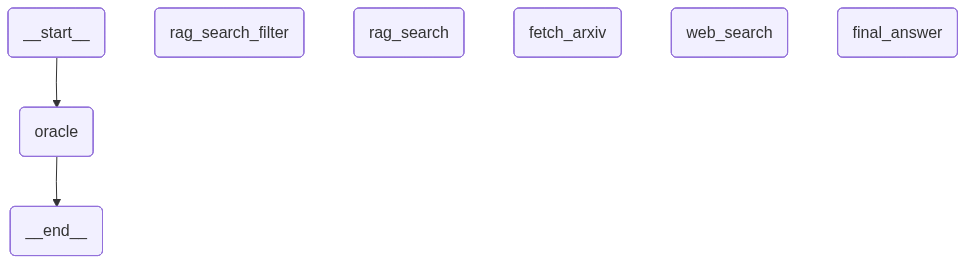

In [48]:
from IPython.display import Image, display

# Display the graph as a PNG using Mermaid rendering.
display(Image(runnable.get_graph().draw_mermaid_png()))

In [51]:
# Run the graph with input.
# output = runnable.invoke({
#     'input': 'Tell me something interesting about Dynamic Backtracking AI and LLMs',
#     'chat_history': [],
# })


## 15 - Generating Reports: Building a Formatted Final Report

In [49]:
def build_report(output: dict) -> str:
    '''Builds a formatted report based on the oracle's output.

    Args:
        output (dict): A dictionary containing the various sections of the report (graph's output).

    Returns:
        str: A formatted string containing the full research report.
    '''
    research_steps = output['research_steps']
    if isinstance(research_steps, list):
        research_steps = '\n'.join([f'- {r}' for r in research_steps])

    sources = output['sources']
    if isinstance(sources, list):
        sources = '\n'.join([f'- {s}' for s in sources])

    return f"""
        INTRODUCTION
        ------------
        {output['introduction']}

        RESEARCH STEPS
        --------------
        {research_steps}

        REPORT
        ------
        {output['main_body']}

        CONCLUSION
        ----------
        {output['conclusion']}

        SOURCES
        -------
        {sources}
    """


In [50]:
# Run the graph with input.
output = runnable.invoke({
    'input': 'Tell me something interesting about Dynamic Backtracking AI and LLMs',
    'chat_history': [],
})

run_oracle
intermediate_steps: []
rag_search.invoke(input={'query': 'Dynamic backtracking algorithm (DBT) in AI: overview, applications to constraint satisfaction problems, differences from chronological backtracking, and connections to large language models (LLMs) such as use in decoding, constraint-guided generation, beam search alternatives, neural-symbolic reasoning, and chain-of-thought. Provide papers, explanations, and examples.'})
run_oracle
intermediate_steps: [AgentAction(tool='rag_search', tool_input={'query': 'Dynamic backtracking algorithm (DBT) in AI: overview, applications to constraint satisfaction problems, differences from chronological backtracking, and connections to large language models (LLMs) such as use in decoding, constraint-guided generation, beam search alternatives, neural-symbolic reasoning, and chain-of-thought. Provide papers, explanations, and examples.'}, log='TBD'), AgentAction(tool='rag_search', tool_input={'query': 'Dynamic backtracking algorithm (D

In [51]:
output['intermediate_steps'][-1].tool_input

{'introduction': 'You asked for something interesting about Dynamic Backtracking (DBT) in AI and how it relates to large language models (LLMs). Below is a short research-style report that explains what DBT is, why it matters, and several concrete and surprising ways its ideas can be applied to LLM-based generation, constrained decoding, and neural–symbolic systems.',
 'research_steps': ['Summarized the core algorithmic idea and historical context of Dynamic Backtracking (DBT) from constraint-satisfaction literature.',
  'Compared DBT to chronological backtracking and related improvements (backjumping, nogood recording).',
  'Mapped DBT concepts onto modern generation and reasoning workflows for LLMs (beam search, Tree of Thoughts, constrained decoding).',
  'Outlined practical examples, potential benefits, and limitations when integrating DBT ideas with LLM systems.'],
 'main_body': 'What DBT is and why it’s neat: Dynamic Backtracking (Ginsberg, early 1990s) is a non‑chronological bac

In [52]:
output = runnable.invoke({
    'input': 'tell me about FIFA World Cup 26',
    'chat_history': []
})


run_oracle
intermediate_steps: []
web_search.invoke(input={'query': 'FIFA World Cup 2026 host cities dates format 48 teams groups of 3 stadiums schedule list'})
run_oracle
intermediate_steps: [AgentAction(tool='web_search', tool_input={'query': 'FIFA World Cup 2026 host cities dates format 48 teams groups of 3 stadiums schedule list'}, log='TBD'), AgentAction(tool='web_search', tool_input={'query': 'FIFA World Cup 2026 host cities dates format 48 teams groups of 3 stadiums schedule list'}, log='FIFA World Cup 2026™ | Fixtures, groups, teams & more\nDiscover the 48 teams taking part in the FIFA World Cup 2026 Canada, Mexico, USA™, including host cities, groups and game dates.\nhttps://www.fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026/articles/fifa-world-cup-2026-hosts-cities-dates-usa-mexico-canada\n---\nWorld Cup 2026 | Match schedule, fixtures & stadiums\nFind out the full match schedule for World Cup 2026 in Canada, Mexico and USA with fixtures and results from each of th

In [54]:
report = build_report(
    output=output['intermediate_steps'][-1].tool_input
)

print(report)


        INTRODUCTION
        ------------
        You asked about the FIFA World Cup 26 (2026). Below is a concise research-style summary covering hosts, dates, format, venues, and key facts about the tournament.

        RESEARCH STEPS
        --------------
        - Checked official FIFA tournament pages for dates, format and host-city information
- Verified tournament structure and match-count from reputable sports references (Wikipedia, ESPN, Britannica)
- Compiled the list of host cities and stadiums announced by FIFA
- Summarized notable changes and practical notes for fans based on official and secondary reporting

        REPORT
        ------
        The 2026 FIFA World Cup (often shortened to World Cup 26 or World Cup 2026) is scheduled to take place from June 11 to July 19, 2026. It will be jointly hosted by the United States, Canada, and Mexico—making it the first World Cup hosted by three countries and the first edition played with an expanded 48-team field. The opening 

In [55]:
output = runnable.invoke({
    'input': 'Create a summary about the future of LLM Agents.',
    'chat_history': []
})

report = build_report(
    output=output['intermediate_steps'][-1].tool_input
)

print(report)

run_oracle
intermediate_steps: []
rag_search.invoke(input={'query': 'future of LLM agents trends, capabilities, research directions, safety, applications, tool use, autonomy, evaluation, orchestration'})
run_oracle
intermediate_steps: [AgentAction(tool='rag_search', tool_input={'query': 'future of LLM agents trends, capabilities, research directions, safety, applications, tool use, autonomy, evaluation, orchestration'}, log='TBD'), AgentAction(tool='rag_search', tool_input={'query': 'future of LLM agents trends, capabilities, research directions, safety, applications, tool use, autonomy, evaluation, orchestration'}, log='Title: Modelling Human Routines: Conceptualising Social Practice Theory for Agent-Based Simulation\nChunk: Agent Systems. Artiﬁcial Intelligence and Law 21(1), 79–107 (8 2012),http://link.springer.com/10.1007/\ns10506-012-9128-5\nDey, A.K.: Understanding and using context. Personal and Ubiquitous Computing 5(1), 4–7 (2001)\nDignum, F.: Interactions as Social Practices: